In [1]:
from PIL import Image

In [2]:
pic=Image.open("image.png")

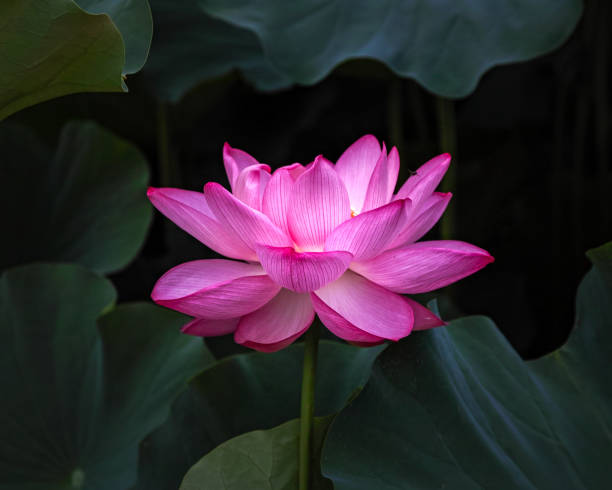

In [3]:
pic

In [4]:
type(pic)

PIL.PngImagePlugin.PngImageFile

In [2]:
import numpy as np


In [6]:
pic_arr=np.asarray(pic)

In [8]:
pic_arr[0]

array([[35, 42, 11],
       [35, 42, 11],
       [35, 42, 11],
       ...,
       [ 8,  8,  6],
       [ 8,  8,  6],
       [ 8,  8,  6]], shape=(612, 3), dtype=uint8)

In [10]:
pic_arr.shape

(490, 612, 3)

In [12]:
pic_arr / 255

array([[[0.1372549 , 0.16470588, 0.04313725],
        [0.1372549 , 0.16470588, 0.04313725],
        [0.1372549 , 0.16470588, 0.04313725],
        ...,
        [0.03137255, 0.03137255, 0.02352941],
        [0.03137255, 0.03137255, 0.02352941],
        [0.03137255, 0.03137255, 0.02352941]],

       [[0.1372549 , 0.16470588, 0.04313725],
        [0.1372549 , 0.16470588, 0.04313725],
        [0.1372549 , 0.16470588, 0.04313725],
        ...,
        [0.03137255, 0.03137255, 0.02352941],
        [0.03137255, 0.03137255, 0.02352941],
        [0.03137255, 0.03137255, 0.02352941]],

       [[0.14117647, 0.16862745, 0.04705882],
        [0.14117647, 0.16862745, 0.04705882],
        [0.14117647, 0.16862745, 0.04705882],
        ...,
        [0.03137255, 0.03137255, 0.02352941],
        [0.03137255, 0.03137255, 0.02352941],
        [0.03137255, 0.03137255, 0.02352941]],

       ...,

       [[0.08235294, 0.13333333, 0.10588235],
        [0.08235294, 0.13333333, 0.10588235],
        [0.08235294, 0

In [3]:
import matplotlib.pyplot as plt

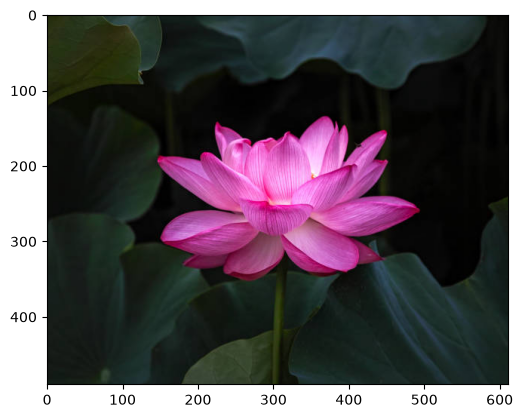

In [17]:
plt.imshow(pic_arr)
# plt.axis('off')

In [22]:
pic_red=pic_arr.copy()

In [23]:
pic_red


array([[[35, 42, 11],
        [35, 42, 11],
        [35, 42, 11],
        ...,
        [ 8,  8,  6],
        [ 8,  8,  6],
        [ 8,  8,  6]],

       [[35, 42, 11],
        [35, 42, 11],
        [35, 42, 11],
        ...,
        [ 8,  8,  6],
        [ 8,  8,  6],
        [ 8,  8,  6]],

       [[36, 43, 12],
        [36, 43, 12],
        [36, 43, 12],
        ...,
        [ 8,  8,  6],
        [ 8,  8,  6],
        [ 8,  8,  6]],

       ...,

       [[21, 34, 27],
        [21, 34, 27],
        [21, 34, 27],
        ...,
        [23, 35, 31],
        [23, 35, 31],
        [23, 35, 31]],

       [[22, 31, 26],
        [22, 31, 26],
        [22, 31, 26],
        ...,
        [23, 35, 31],
        [23, 35, 31],
        [23, 35, 31]],

       [[22, 31, 26],
        [22, 31, 26],
        [22, 31, 26],
        ...,
        [23, 35, 31],
        [23, 35, 31],
        [23, 35, 31]]], shape=(490, 612, 3), dtype=uint8)

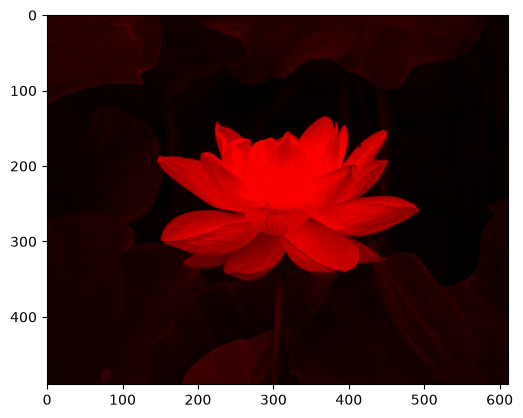

In [ ]:
#RGB
#012f
pic_red[:,:,1] = 0 # green channel -> zero
pic_red[:,:,2]=0 # blue channel -> zero

plt.imshow(pic_red)

In [5]:
import cv2
img=cv2.imread("image.png")


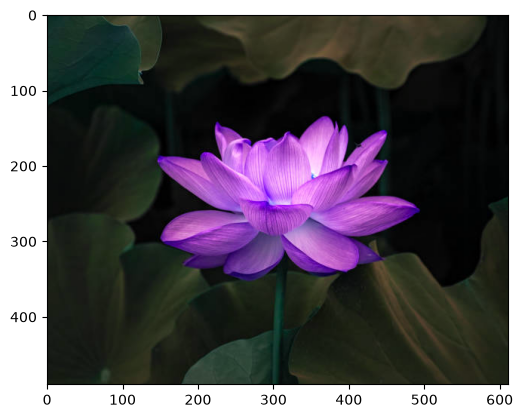

In [ ]:
plt.imshow(img) # the color is not correct because cv2 reads the image in BGR format

In [7]:
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

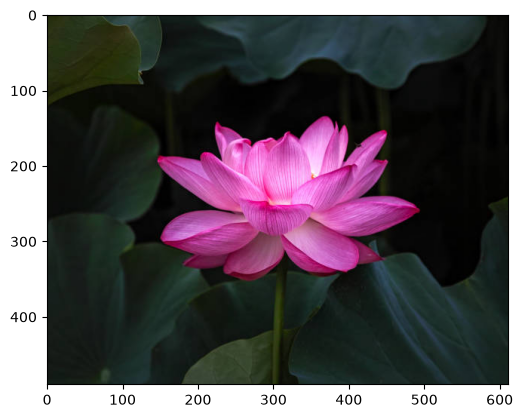

In [9]:
plt.imshow(img_rgb)

(np.float64(-0.5), np.float64(611.5), np.float64(489.5), np.float64(-0.5))

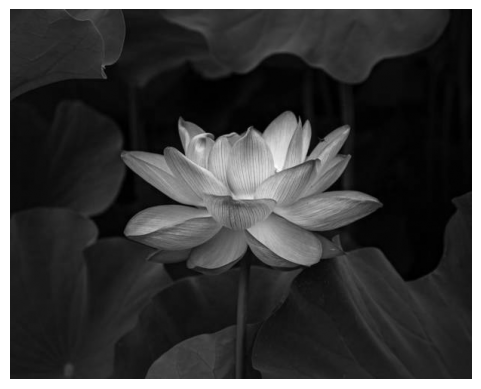

In [13]:
img_gray=cv2.imread("image.png",cv2.IMREAD_GRAYSCALE)
plt.imshow(img_gray,cmap="gray")
plt.axis(False)

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

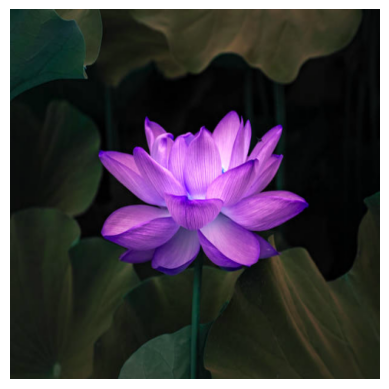

In [16]:
img_resize=cv2.resize(img,(500,500))
plt.imshow(img_resize)
plt.axis(False)

(np.float64(-0.5), np.float64(305.5), np.float64(244.5), np.float64(-0.5))

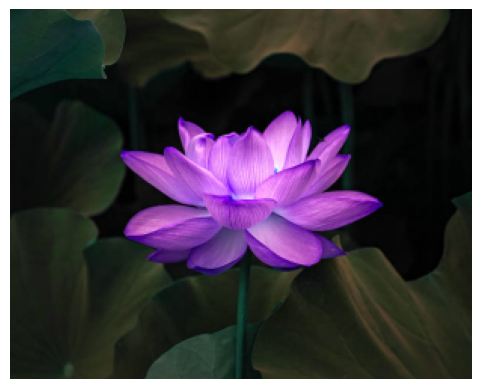

In [17]:
w_ratio=.5
h_ratio=.5
new_img=cv2.resize(img,(0,0),fx=w_ratio,fy=h_ratio)
plt.imshow(new_img)
plt.axis(False)

### generationg faces using diffusion model

In [7]:
from diffusers import DDPMPipeline # denoising diffusion probabilistic model

In [8]:
ddpm=DDPMPipeline.from_pretrained("google/ddpm-celebahq-256").to("cuda")

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\vikas\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\vikas\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [42]:
image=ddpm(num_inference_steps=30).images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

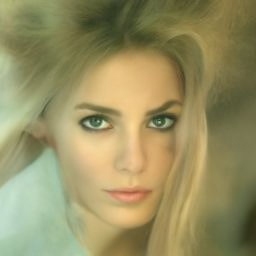

In [43]:
image

In [44]:
from diffusers import DDPMScheduler, UNet2DModel # Scheduler is used to control the denoising process, UNet2DModel is the architecture of the model
scheduler=DDPMScheduler.from_pretrained("google/ddpm-celebahq-256")


In [45]:
scheduler

DDPMScheduler {
  "_class_name": "DDPMScheduler",
  "_diffusers_version": "0.39.0",
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_start": 0.0001,
  "clip_sample": true,
  "clip_sample_range": 1.0,
  "dynamic_thresholding_ratio": 0.995,
  "num_train_timesteps": 1000,
  "prediction_type": "epsilon",
  "rescale_betas_zero_snr": false,
  "sample_max_value": 1.0,
  "steps_offset": 0,
  "thresholding": false,
  "timestep_spacing": "leading",
  "trained_betas": null,
  "variance_type": "fixed_small"
}

In [46]:
model=UNet2DModel.from_pretrained("google/ddpm-celebahq-256").to("cuda")

An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [47]:
model

UNet2DModel(
  (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0-1): 2 x DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Con

In [48]:
scheduler.set_timesteps(50) # what it does is it sets the number of timesteps for the denoising process. The more timesteps, the better the quality of the generated image, but it will take longer to generate.

In [49]:
import torch
sample_size=model.config.sample_size

In [50]:
sample_size

256

In [51]:
noise=torch.randn((1,3,sample_size,sample_size),device="cuda")

In [52]:
noise

tensor([[[[ 1.0312,  0.2494, -1.2192,  ...,  0.2525,  0.8381,  0.1994],
          [-1.7193,  1.7312,  0.5380,  ...,  0.1896, -0.8584,  0.7939],
          [ 0.3684, -0.0974, -0.4164,  ...,  0.7096,  0.7733,  0.0042],
          ...,
          [-0.2221, -0.2986,  1.6975,  ..., -0.4336,  1.2037,  1.2891],
          [-0.5813,  0.7944,  2.8648,  ...,  0.5560, -1.1199, -0.3322],
          [ 0.1361,  0.9813,  0.0979,  ...,  1.4392,  0.3748,  0.4990]],

         [[ 2.6606,  0.3962, -0.1772,  ...,  1.2325, -1.6977, -0.3586],
          [-1.2493,  0.1933,  1.0124,  ..., -0.7135, -0.6888, -0.6886],
          [ 0.2159, -0.3285, -0.3953,  ...,  0.0349, -0.5591,  1.2660],
          ...,
          [-0.4509,  1.7789,  0.0480,  ..., -1.9675, -0.3609, -0.2837],
          [ 1.0434,  0.4168, -1.1158,  ..., -0.1264,  0.2755, -0.5654],
          [ 0.6589,  1.9386,  1.6874,  ..., -0.3471,  0.9038,  1.5805]],

         [[-1.9730,  1.7049,  0.1401,  ..., -0.7169, -0.6984, -0.5652],
          [-0.8424,  1.1095, -

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0166907..4.137996].


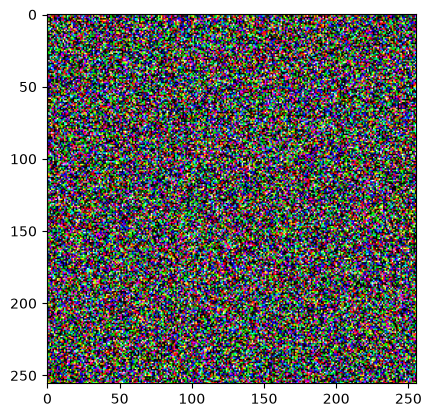

In [53]:
import matplotlib.pyplot as plt
input=noise
plt.imshow(input.squeeze().permute(1,2,0).detach().to("cpu").numpy())

In [54]:
for t in scheduler.timesteps:
    with torch.inference_mode():
        noisy_residual=model(input,t).sample
        
        previous_noisy_sample=scheduler.step(noisy_residual, t ,input).prev_sample
        input=previous_noisy_sample

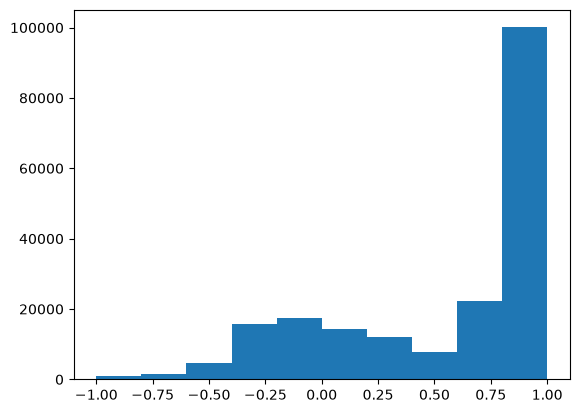

In [55]:
plt.hist(input.squeeze().permute(1,2,0).detach().to("cpu").numpy().flatten());

In [56]:
from PIL import Image
import numpy as np


In [57]:
image=(input/2+0.5).clamp(0,1).squeeze()


In [58]:
image=(image.permute(1,2,0)*255).round().to(torch.uint8).cpu().numpy()

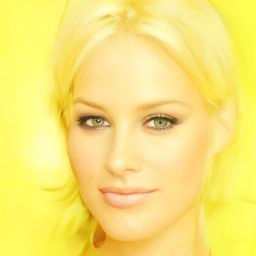

In [59]:
image=Image.fromarray(image)
image

### generation images using diffusion model

In [ ]:
import torch
from diffusers import DiffusionPipeline

pipe=DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0",dtype=torch.bfloat16,device_map="cuda")

prompt="Astronaut in  a jungle , cold color palette, muted color,detailed 8k"
image=pipe(prompt).images[0]